# Observe the data and look at the bias

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image

In [2]:
# reference training images folder:
train_images_folder = "Data/Training/Training_Images"

# reference csv:
train_csv = "Data/Training/Training_LabelsDemographic.csv"
# load in csv:
train_df = pd.read_csv(train_csv)

# csv columns: 'image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center'
print("train_csv columns: ", train_df.columns)

train_csv columns:  Index(['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight',
       'data_center'],
      dtype='str')


#### Look at the bias in the data:

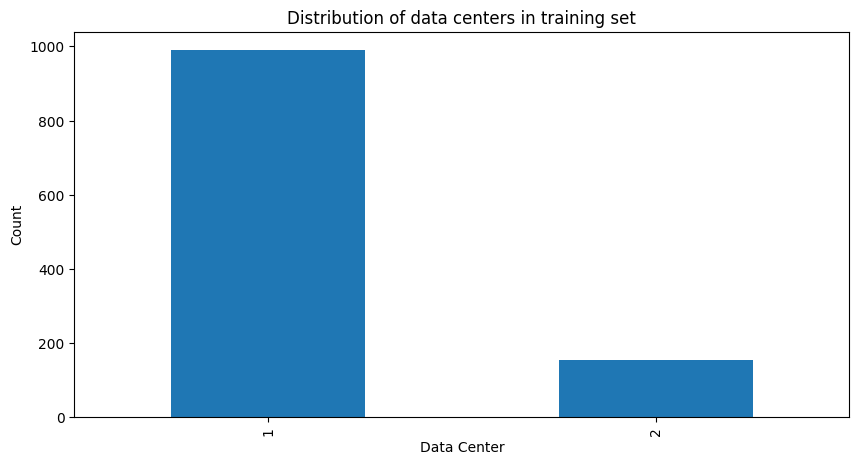

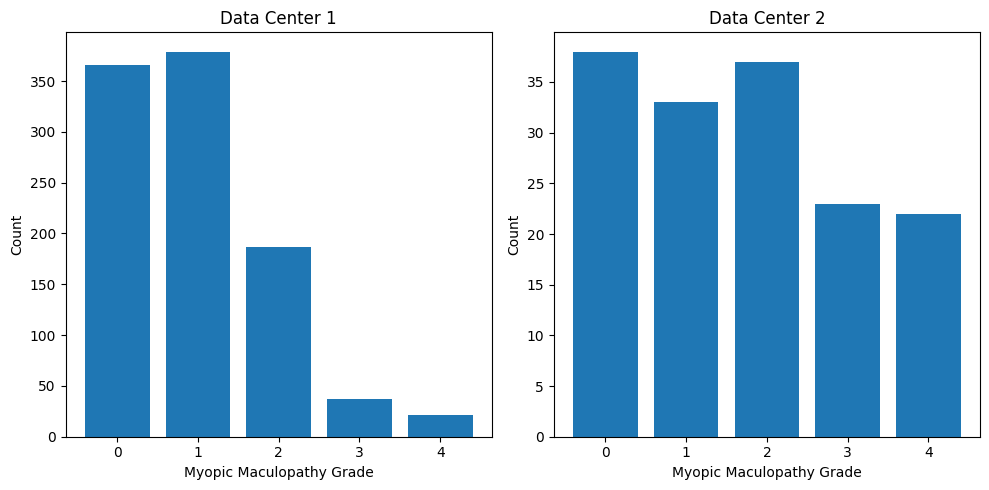

Samples per data center:
data_center
1    990
2    153
Name: count, dtype: int64


In [32]:
# counts by dataset:
plt.figure(figsize=(10, 5))
train_df["data_center"].value_counts().plot(kind="bar")
plt.title("Distribution of data centers in training set")
plt.xlabel("Data Center")
plt.ylabel("Count")
plt.show()

# myopic maculopathy grade bar plots for each center side by side, using plt.bar:
plt.figure(figsize=(10, 5))
for i, center in enumerate(train_df["data_center"].unique()):
    plt.subplot(1, len(train_df["data_center"].unique()), i + 1)
    plt.bar(train_df[train_df["data_center"] == center]["myopic_maculopathy_grade"].value_counts().sort_index().index,
            train_df[train_df["data_center"] == center]["myopic_maculopathy_grade"].value_counts().sort_index().values)
    plt.title(f"Data Center {center}")
    plt.xlabel("Myopic Maculopathy Grade")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# print number of samples from each data center:
print("Samples per data center:")
print(train_df["data_center"].value_counts())

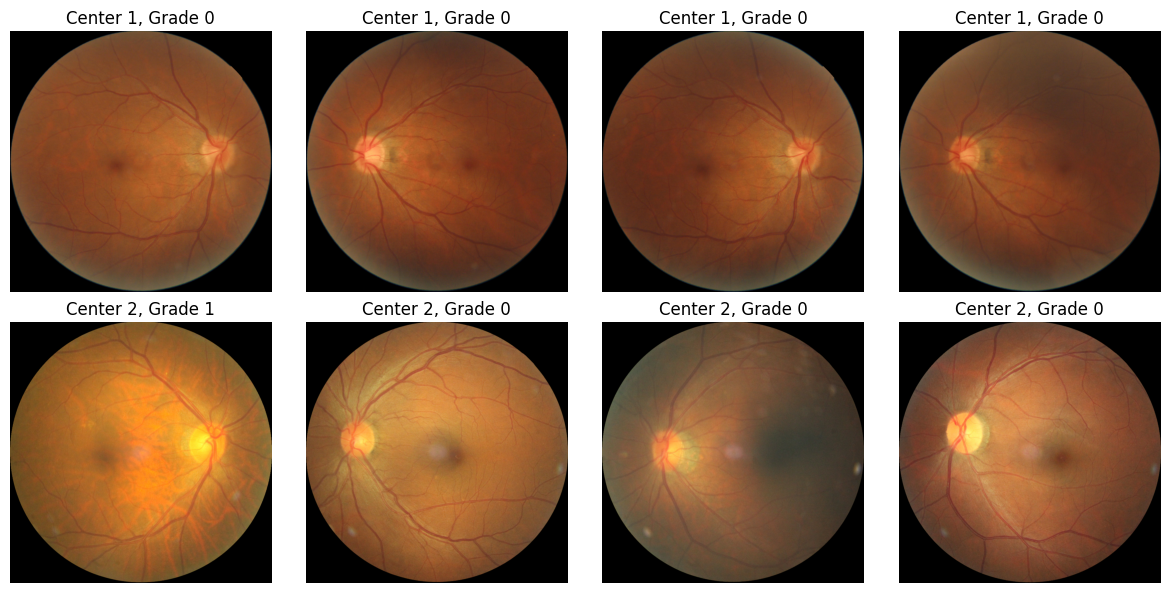

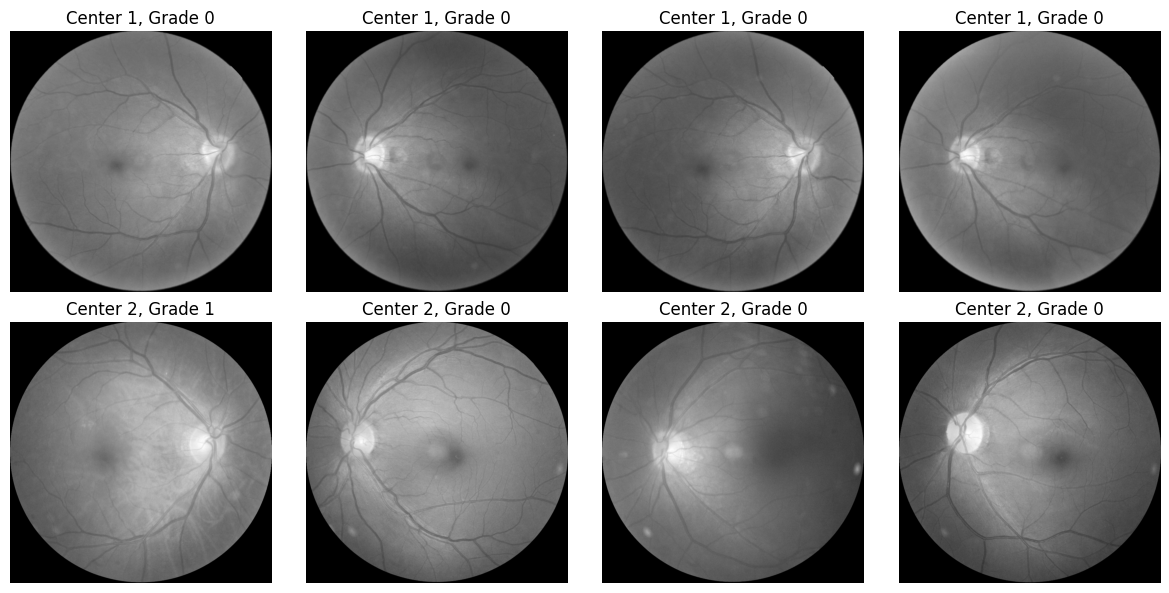

In [7]:
# load four examples from center 1 and four from center 2, and display them in a 2x4 grid 
# with titles showing the grade and center:
plt.figure(figsize=(12, 6))
for i, center in enumerate(train_df["data_center"].unique()):
    center_df = train_df[train_df["data_center"] == center]
    for j in range(4):
        img_name = center_df.iloc[j]["image"]
        img_path = os.path.join(train_images_folder, img_name)
        img = Image.open(img_path)
        plt.subplot(2, 4, i * 4 + j + 1)
        plt.imshow(img, cmap="gray")
        grade = center_df.iloc[j]["myopic_maculopathy_grade"]
        plt.title(f"Center {center}, Grade {grade}")
        plt.axis("off")
plt.tight_layout()
plt.show()

The images from the two centers differ significantly in illumination - the images from center 2 are much brighter - we will need to correct for this bias.

Processing Center 2: 100%|██████████| 38/38 [00:00<00:00, 116.99it/s]


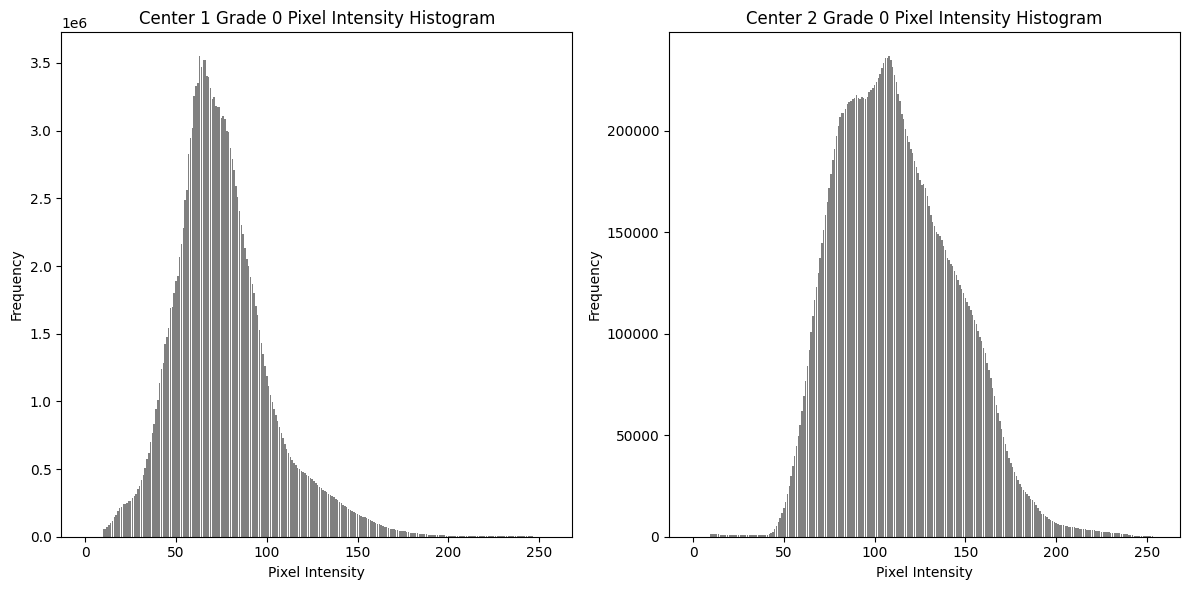

In [6]:
# go through all images of grade 0, convert to grayscale and histogram intensities
# do this for both centers and plot the histograms side by side:
# use tqdm to show progress as this may take a while:
from tqdm import tqdm
plt.figure(figsize=(12, 6))
for i, center in enumerate(train_df["data_center"].unique()):
    center_df = train_df[train_df["data_center"] == center]
    grade_0_df = center_df[center_df["myopic_maculopathy_grade"] == 0]
    all_pixels = []
    hist = np.zeros(256)
    for img_name in tqdm(grade_0_df["image"], desc=f"Processing Center {center}"):
        img_path = os.path.join(train_images_folder, img_name)
        img = Image.open(img_path).convert("L")
        pixels = np.array(img).flatten()
        hist += np.histogram(pixels, bins=256, range=(0, 255))[0]
        # discard all values below 10 as these are background zeros
        hist[:10] = 0
    plt.subplot(1, 2, i + 1)
    plt.bar(np.arange(256), hist, color="gray")
    plt.title(f"Center {center} Grade 0 Pixel Intensity Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Unique values of sex:  <StringArray>
['male', 'female', nan]
Length: 3, dtype: str
Number of nans in sex column:  153


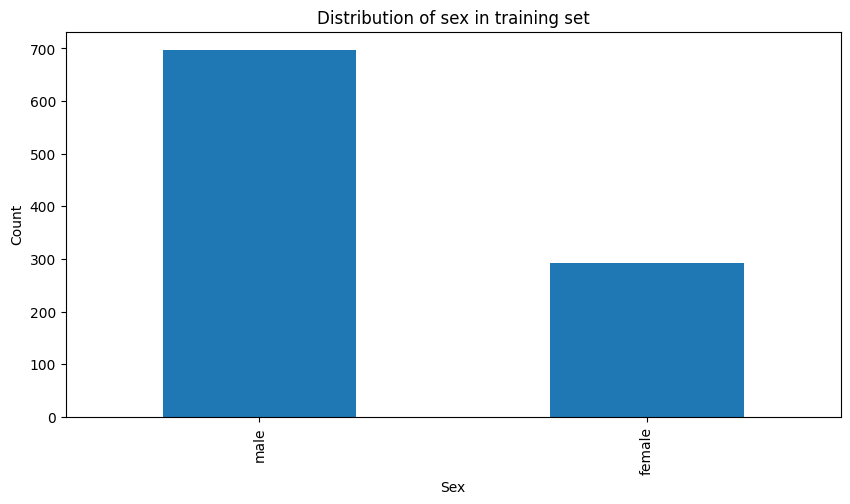

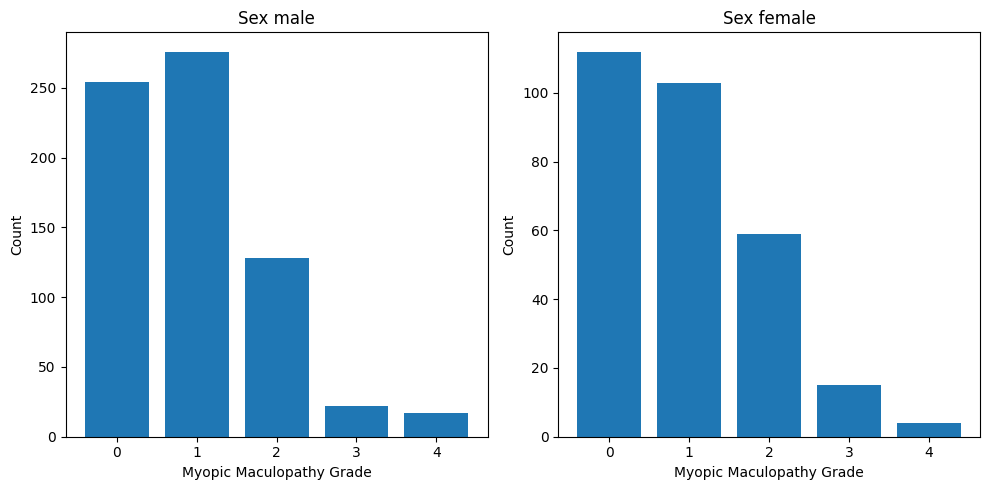

Samples per sex:
sex
male      697
female    293
Name: count, dtype: int64


In [34]:
# print value range of sex:
print("Unique values of sex: ", train_df["sex"].unique())
# print number of nans:
print("Number of nans in sex column: ", train_df["sex"].isna().sum())

# counts by sex:
plt.figure(figsize=(10, 5))
train_df["sex"].value_counts().plot(kind="bar")
plt.title("Distribution of sex in training set")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# myopic maculopathy grade bar plots for each sex side by side, using plt.bar:
plt.figure(figsize=(10, 5))
for i, sex in enumerate(train_df["sex"].dropna().unique()):
    plt.subplot(1, len(train_df["sex"].dropna().unique()), i + 1)
    plt.bar(train_df[train_df["sex"] == sex]["myopic_maculopathy_grade"].value_counts().sort_index().index,
            train_df[train_df["sex"] == sex]["myopic_maculopathy_grade"].value_counts().sort_index().values)
    plt.title(f"Sex {sex}")
    plt.xlabel("Myopic Maculopathy Grade")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# print number of samples for each sex:
print("Samples per sex:")
print(train_df["sex"].value_counts())

Lowest age:  29
Highest age:  93


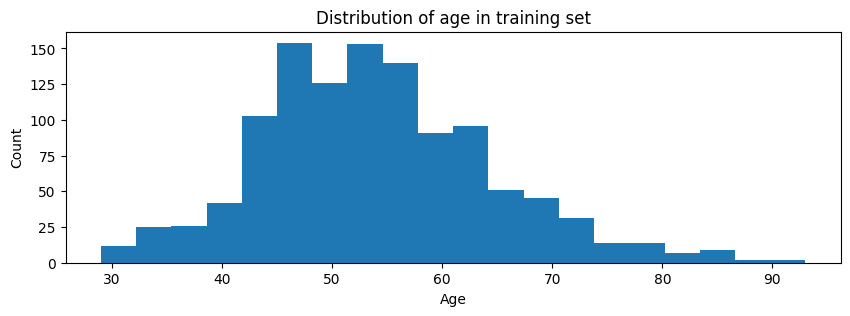

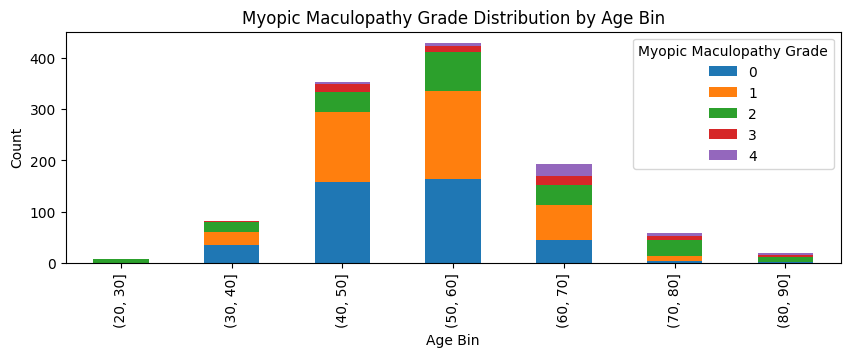

In [36]:
# print lowest and highest age:
print("Lowest age: ", train_df["age"].min())
print("Highest age: ", train_df["age"].max())

# age histogram:
plt.figure(figsize=(10, 3))
plt.hist(train_df["age"], bins=20)
plt.title("Distribution of age in training set")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# bin ages into 10 year bins, grade range for each:
train_df["age_bin"] = pd.cut(train_df["age"], bins=range(0, 100, 10))
age_bin_grade_counts = train_df.groupby("age_bin")["myopic_maculopathy_grade"].value_counts().unstack().fillna(0)
age_bin_grade_counts.plot(kind="bar", stacked=True, figsize=(10, 3))
plt.title("Myopic Maculopathy Grade Distribution by Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Count")
plt.legend(title="Myopic Maculopathy Grade")
plt.show()

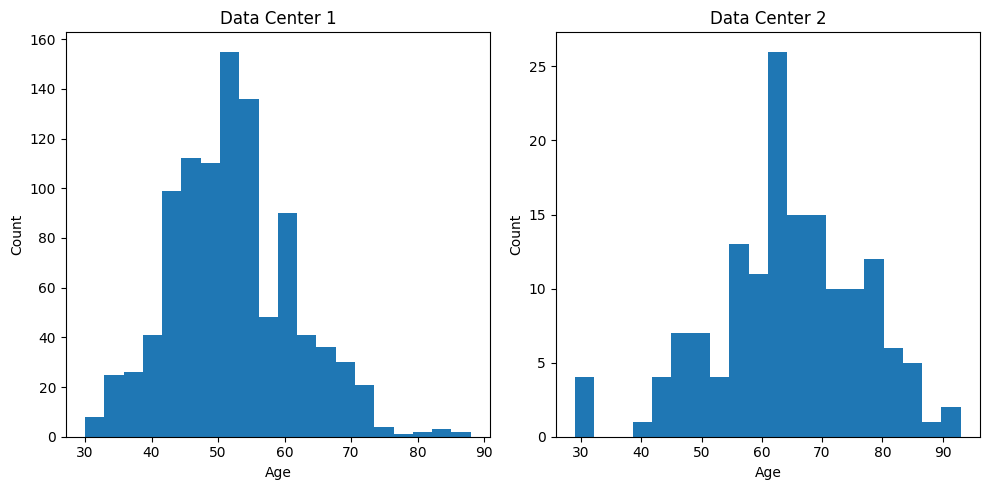

In [29]:
# plot age distribution by data center:
plt.figure(figsize=(10, 5))
for i, center in enumerate(train_df["data_center"].unique()):
    plt.subplot(1, len(train_df["data_center"].unique()), i + 1)
    plt.hist(train_df[train_df["data_center"] == center]["age"], bins=20)
    plt.title(f"Data Center {center}")
    plt.xlabel("Age")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, kruskal
from statsmodels.stats.multitest import multipletests

# function to perform chi-square test and calculate cramers V
# chi-square test is used to test for association between two (categorical) variabes.
# case, we are testing for association between the group variable (data center, sex, age bin) 
# and myopic maculopathy classification, which would indicate bias in the training data if there 
# is a significant association. 
# 
# Cramer's V is a measure of effect size for the chi-square test, which gives us an idea of how 
# strong the association is if it exists.
def chi_square_with_effect(df, group_col, label_col="myopic_maculopathy_grade"):
    tmp = df[[group_col, label_col]].dropna().copy() # drop nans
    table = pd.crosstab(tmp[group_col], tmp[label_col]) # 

    chi2, p, dof, _ = chi2_contingency(table) # chi-square test
    n = table.values.sum() # total samples
    r, k = table.shape # number of rows/columns in contingency table
    # the contingency table is the cross-tabulation of the group variable (e.g. data center) 
    # and the label variable (myopic maculopathy grade), so the number of rows is the number 
    # of unique groups and the number of columns is the number of unique grades
    denom = max(min(r - 1, k - 1), 1) # avoid division by zero by ensuring denom is at least 1
    cramers_v = np.sqrt((chi2 / n) / denom)

    return {
        "group": group_col, # group (e.g. data center, age or sex)
        "chi2": chi2, # chi-square value
        "p": p, # p-value of chi squared
        "dof": dof, # degrees of freedom for chi-squared
        "cramers_v": cramers_v, # effect size of the bias
        "n": n # total samples used in test
    }

# Build age bins for categorical age test
train_df["age_bin_test"] = pd.cut(train_df["age"], bins=range(0, 101, 10), include_lowest=True)

# chi suquare tests for data center, sex and age bins
tests = []
for g in ["data_center", "sex", "age_bin_test"]:
    tests.append(chi_square_with_effect(train_df, g))

# correct for multiple testing
# use multipletests from statsmodels - this function takes list of p-values and applies
# multiple testing correction (i.e. adjusts p-values to control for false discovery rate)
# this is done by applying the Benjamini-Hochberg procedure, which controls the expected
# proportion of false discoveries among the rejected hypotheses
res = pd.DataFrame(tests) # dataframe of test results
res["p_fdr"] = multipletests(res["p"], method="fdr_bh")[1] # adjusted p-values
res["significant_fdr_0.05"] = res["p_fdr"] < 0.05 # mark significant results
display(res.sort_values("p_fdr")) # display test results (by descending significance)

# Continuous age vs grade (distributional shift across grades)
# we use the Kruskal-Wallis test to compare the age distributions across the different 
# myopic maculopathy grades, as this test does not assume any specific age distribution
age_groups = [x["age"].dropna().values for _, x in train_df.groupby("myopic_maculopathy_grade")] # group ages by grade, remove nans
H, p_kw = kruskal(*age_groups) # (* unpacks array list into separate arguments, as expected by kruskal)
print(f"Kruskal-Wallis age~grade: H={H:.3f}, p={p_kw:.3e}")

# a kruskal-wallis score of 0 would indicate that the age distributions are identical 
# across all maculopathy grades. 
# The p-value indicates whether the observed differences are statistically significant.
# we use 0.05 for significance.

,group,chi2,p,dof,cramers_v,n,p_fdr,significant_fdr_0.05
2,age_bin_test,238.266876,3.197815e-35,28,0.228286,1143,9.593446e-35,True
0,data_center,102.822238,2.465234e-21,4,0.299930,1143,3.697851e-21,True
1,sex,4.833316,3.048318e-01,4,0.069872,990,3.048318e-01,False


Kruskal-Wallis age~grade: H=111.761, p=3.065e-23


#### Load a trained classification model and test performance

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm


# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [12]:
# define a custom dataset class for loading the images and labels
class MyopicMaculopathyDataset(Dataset):
    def __init__(self, csv_file, images_folder, transform=None):
        self.data = pd.read_csv(csv_file)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.images_folder, self.data.iloc[idx]["image"])
        image = Image.open(img_name).convert("RGB") # RGBA to RGB
        label = self.data.iloc[idx]["myopic_maculopathy_grade"] # corresponding 0-4 label
        if self.transform:
            image = self.transform(image) # apply transform
        return image, label


In [10]:
# compute training-set RGB mean/std (after resizing) for normalisation
stats_resize = (224, 224)
channel_sum = np.zeros(3, dtype=np.float64)
channel_sq_sum = np.zeros(3, dtype=np.float64)
num_pixels = 0

for filename in train_df["image"]:
    img_path = os.path.join(train_images_folder, filename)
    img = Image.open(img_path).convert("RGB").resize(stats_resize)
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [H, W, C] in [0, 1]
    flat = arr.reshape(-1, 3)
    channel_sum += flat.sum(axis=0)
    channel_sq_sum += (flat ** 2).sum(axis=0)
    num_pixels += flat.shape[0]

train_mean = (channel_sum / num_pixels).tolist()
train_std = np.sqrt(channel_sq_sum / num_pixels - np.array(train_mean) ** 2).tolist()
print("train_mean:", train_mean)
print("train_std:", train_std)

# define transformations for the images
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # keep full RGB channels
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
    # this applies (x - mean)/(std per channel)
])

train_mean: [0.43155672973894904, 0.21262072526255182, 0.05879379318795628]
train_std: [0.2834394277616389, 0.162047321157112, 0.0910429572794565]


/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 8/8 [00:02<00:00,  3.90it/s]


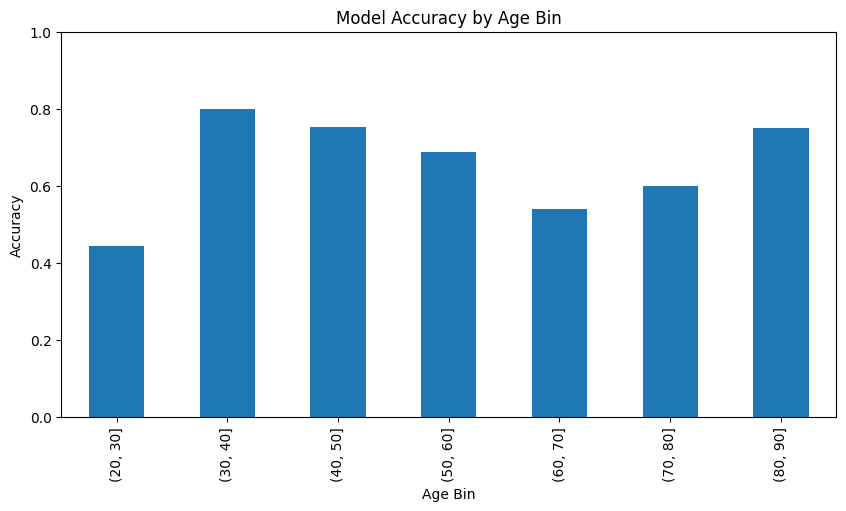

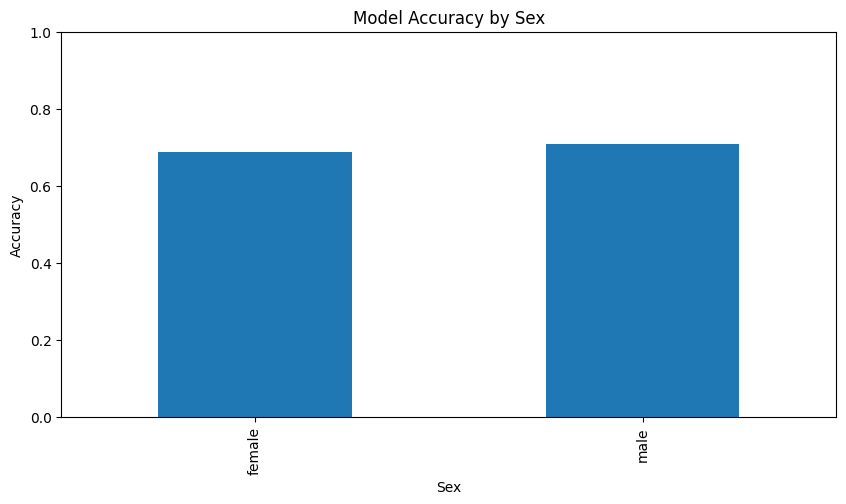

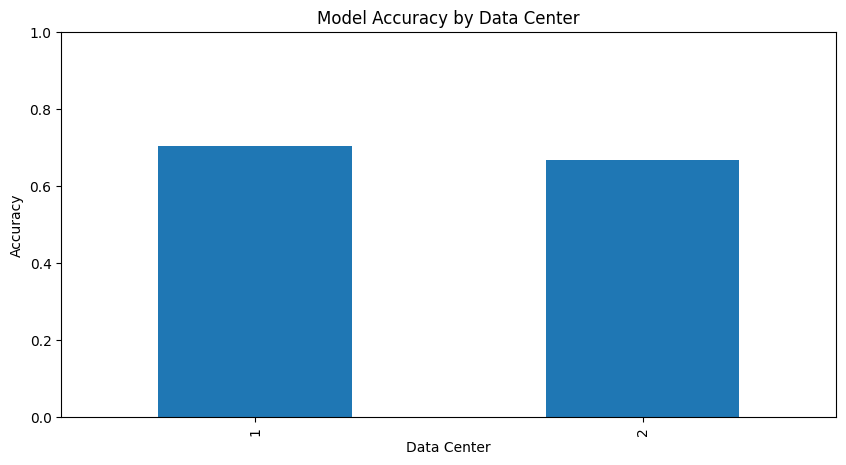

In [14]:
# load a trained classification model and plot performance by age, sex, data_center:

# load the model:
model_loaded = models.resnet18(pretrained=True)
num_ftrs = model_loaded.fc.in_features
model_loaded.fc = nn.Linear(num_ftrs, 5) # modify the final layer to output 5 classes (grades 0-4)
model_loaded.load_state_dict(torch.load("myopic_maculopathy_resnet18_class_weights.pth"))
model_loaded = model_loaded.to(device)
model_loaded.eval()

# make a test dataloader:
test_csv = "Data/Testing/Testing_LabelDemographic.csv"
test_images_folder = "Data/Testing/Testing_Images"
test_dataset = MyopicMaculopathyDataset(csv_file=test_csv, images_folder=test_images_folder, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# get predictions and true labels for the test set:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_loaded(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy()) 
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# plot performance by age, sex, data_center:
test_df = pd.read_csv(test_csv)
test_df["predicted_grade"] = all_preds

# accuracy by age bin:
test_df["age_bin"] = pd.cut(test_df["age"], bins=range(0, 100, 10))
age_bin_accuracy = test_df.groupby("age_bin").apply(lambda x: (x["predicted_grade"] == x["myopic_maculopathy_grade"]).mean())
age_bin_accuracy.plot(kind="bar", figsize=(10, 5))
plt.title("Model Accuracy by Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# accuracy by sex:
sex_accuracy = test_df.groupby("sex").apply(lambda x: (x["predicted_grade"] == x["myopic_maculopathy_grade"]).mean())
sex_accuracy.plot(kind="bar", figsize=(10, 5))
plt.title("Model Accuracy by Sex")
plt.xlabel("Sex")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# accuracy by data center:
center_accuracy = test_df.groupby("data_center").apply(lambda x: (x["predicted_grade"] == x["myopic_maculopathy_grade"]).mean())
center_accuracy.plot(kind="bar", figsize=(10, 5))
plt.title("Model Accuracy by Data Center")
plt.xlabel("Data Center")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Now use inverse probability weighting to account for bias

In [16]:
# we can use inverse probability weighting to account for bias in the training data
# for example, by center

# implement inverse probability weighting and retrain

# inverse probability weighting, we assign a weight to each sample that is inversely 
# proportional to the frequency of its class in the training data. This way, samples 
# from biased classes get higher weights, and samples from less biased classes get 
# lower weights. We can implement this by calculating the class frequencies
class_counts = train_df["data_center"].value_counts()
class_weights = 1.0 / class_counts
sample_weights = train_df["data_center"].map(class_weights)
sample_weights = torch.from_numpy(sample_weights.values).float()
train_dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=32, sampler=torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights)))

# now we can retrain the model using this weighted dataloader and see if it improves performance on the test set, especially for underrepresented centers.
# retrain:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 24
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_dataloader.dataset)
    print(f"Epoch {epoch + 1} Loss: {epoch_loss:.4f}")

# save the model:
torch.save(model.state_dict(), "myopic_maculopathy_resnet18_bias_weights_retrained.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.45it/s]


Epoch 1 Loss: 0.5004


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]


Epoch 2 Loss: 0.1766


Epoch 3/24: 100%|██████████| 36/36 [00:16<00:00,  2.13it/s]


...

Epoch 22 Loss: 0.0077


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.47it/s]


Epoch 23 Loss: 0.0025


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.44it/s]

Epoch 24 Loss: 0.0012


100%|██████████| 8/8 [00:02<00:00,  3.38it/s]


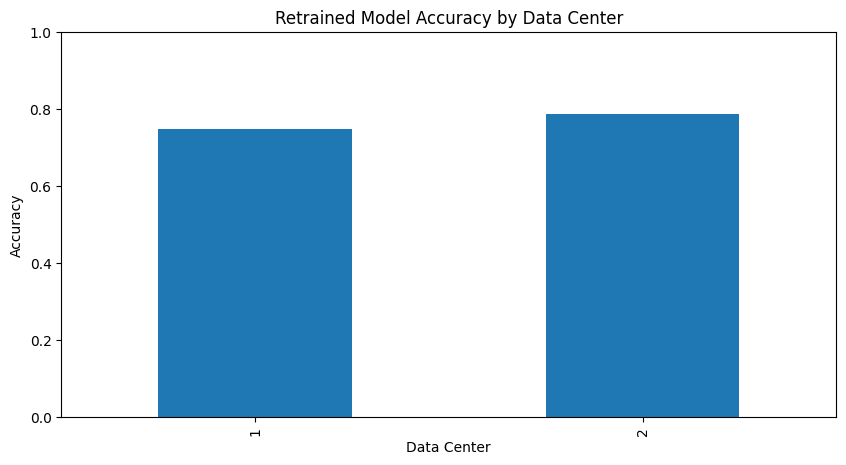

In [19]:
# now we can evaluate the retrained model on the test set and compare performance by data center:
model_loaded.load_state_dict(torch.load("myopic_maculopathy_resnet18_bias_weights_retrained.pth"))
model_loaded.eval()

# get predictions and true labels for the test set:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_loaded(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_df["predicted_grade"] = all_preds

# accuracy by data center:
center_accuracy = test_df.groupby("data_center").apply(lambda x: (x["predicted_grade"] == x["myopic_maculopathy_grade"]).mean())
center_accuracy.plot(kind="bar", figsize=(10, 5))
plt.title("Retrained Model Accuracy by Data Center")
plt.xlabel("Data Center")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.49it/s]


Epoch 1 Loss: 0.4737


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.56it/s]


Epoch 2 Loss: 0.1713


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.54it/s]


...

Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]


Epoch 23 Loss: 0.0111


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]


Epoch 24 Loss: 0.0150


100%|██████████| 8/8 [00:02<00:00,  3.58it/s]


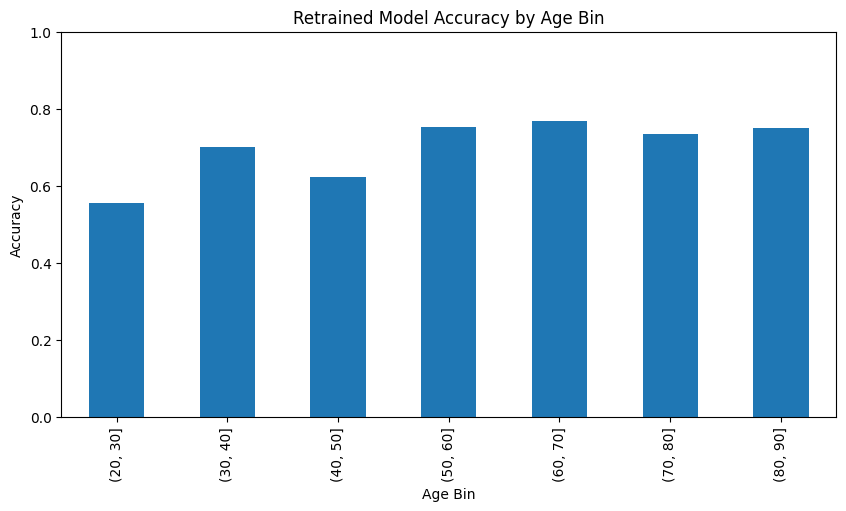

In [22]:
# now retrain but with inverse on age bins

# use pd.cut to bin ages into 10 year bins, and then calculate 
# class weights based on age bins instead of data center

# age bins that always cover full age range
max_age = int(np.ceil(train_df["age"].max()))
bin_edges = list(range(0, max_age + 10, 10))
if bin_edges[-1] <= max_age:
    bin_edges.append(max_age + 10)

# modify train_df to include the age bins:
train_df["age_bin"] = pd.cut(train_df["age"], bins=bin_edges, include_lowest=True)

# inverse-probability weights
age_bin_counts = train_df["age_bin"].value_counts()
age_bin_weights = 1.0 / age_bin_counts
sample_weights = train_df["age_bin"].map(age_bin_weights).astype(float)

# make sampler-safe (no nan valies)
sample_weights = sample_weights.fillna(0.0) # no nan, if nan then set to 0
sample_weights = torch.as_tensor(sample_weights.values, dtype=torch.double) # torch tensor

# sanity check for debugging
assert torch.isfinite(sample_weights).all(), "Non-finite weights found"
assert (sample_weights >= 0).all(), "Negative weights found"
assert sample_weights.sum() > 0, "All weights are zero"

# set up train dataset and dataloader
train_dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=torch.utils.data.WeightedRandomSampler(
        sample_weights, num_samples=len(sample_weights), replacement=True
    ),
)

# retrain:
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) 

num_epochs = 24
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_dataloader.dataset)
    print(f"Epoch {epoch + 1} Loss: {epoch_loss:.4f}")

# save the model:
torch.save(model.state_dict(), "myopic_maculopathy_resnet18_age_weights_retrained.pth")


100%|██████████| 8/8 [00:02<00:00,  3.62it/s]


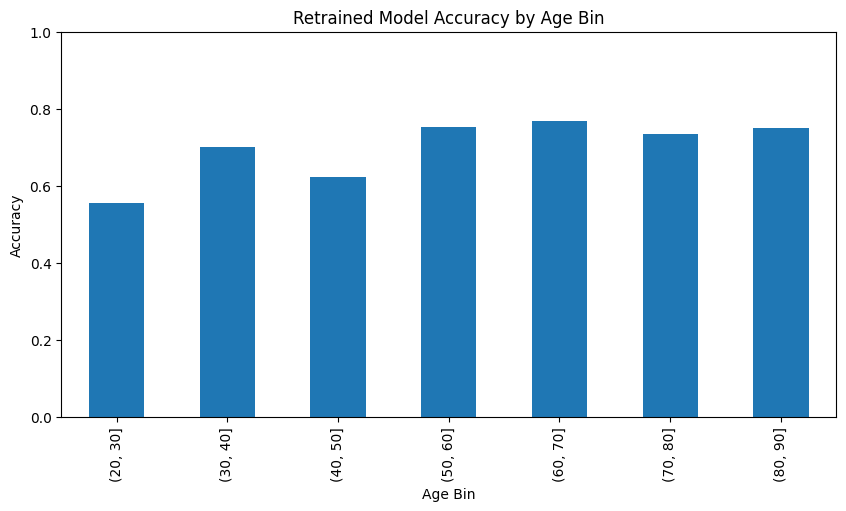

In [23]:

# evaluate on test set:
model_loaded.load_state_dict(torch.load("myopic_maculopathy_resnet18_age_weights_retrained.pth"))
model_loaded.eval() 

# get predictions and true labels for the test set:
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_loaded(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)   

test_df["predicted_grade"] = all_preds

# accuracy by age bin:
age_bin_accuracy = test_df.groupby("age_bin").apply(lambda x: (x["predicted_grade"] == x["myopic_maculopathy_grade"]).mean())
age_bin_accuracy.plot(kind="bar", figsize=(10, 5))
plt.title("Retrained Model Accuracy by Age Bin")
plt.xlabel("Age Bin")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Correct for all sources of bias simultaneously:

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Joint-weighted epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.49it/s]


Epoch 1 Loss: 0.5135


Joint-weighted epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.57it/s]


Epoch 2 Loss: 0.1659


Joint-weighted epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.56it/s]


...

Joint-weighted epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]


Epoch 23 Loss: 0.0064


Joint-weighted epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]


Epoch 24 Loss: 0.0054


Evaluating joint-weighted model: 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]


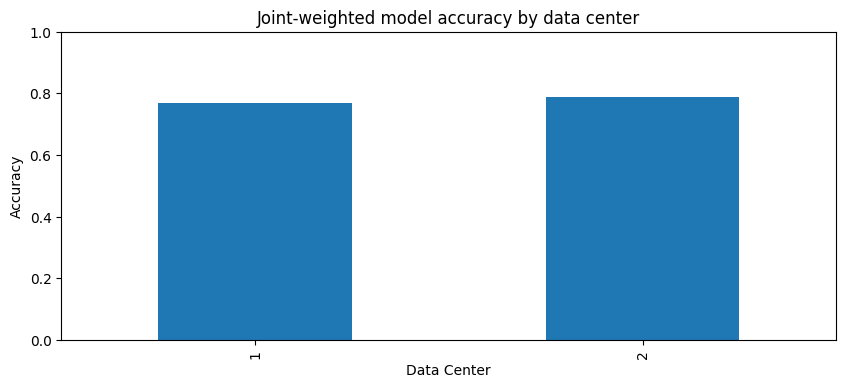

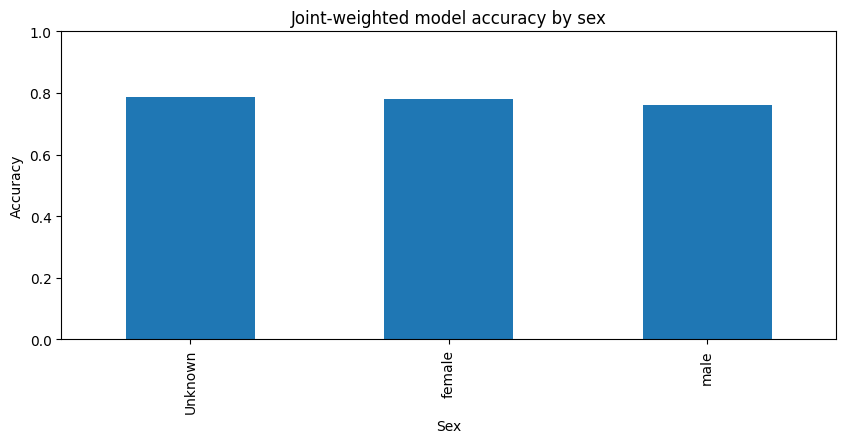

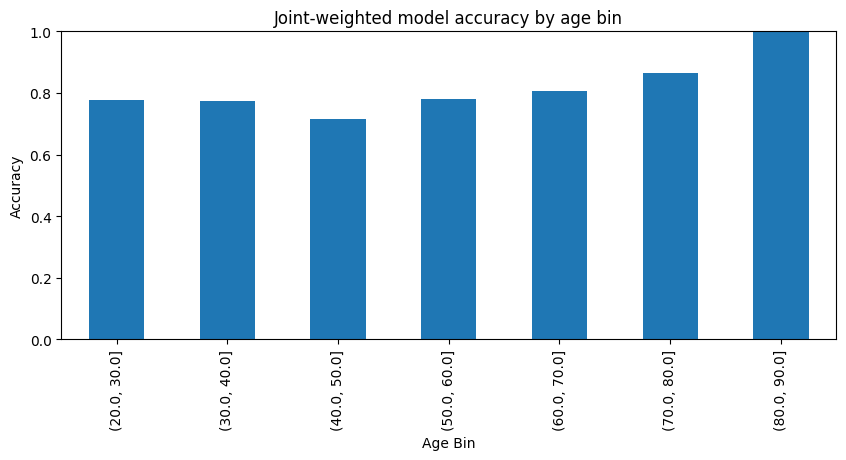

Worst 10 intersectional groups (center, age_bin, sex):
data_center  age_bin       sex    
1            (30.0, 40.0]  female     0.642857
             (40.0, 50.0]  male       0.649123
             (20.0, 30.0]  male       0.666667
2            (50.0, 60.0]  Unknown    0.687500
1            (60.0, 70.0]  female     0.714286
             (50.0, 60.0]  female     0.750000
             (20.0, 30.0]  female     0.750000
             (50.0, 60.0]  male       0.816327
             (60.0, 70.0]  male       0.833333
             (70.0, 80.0]  female     0.833333
Name: correct, dtype: float64

Best 10 intersectional groups (center, age_bin, sex):
data_center  age_bin       sex    
1            (60.0, 70.0]  male       0.833333
             (70.0, 80.0]  female     0.833333
             (30.0, 40.0]  male       0.846154
2            (60.0, 70.0]  Unknown    0.857143
             (70.0, 80.0]  Unknown    0.875000
1            (40.0, 50.0]  female     0.900000
             (70.0, 80.0]  male       

In [24]:
# Joint inverse-probability weighting across data_center + age_bin + sex
# This trains one model that upweights underrepresented intersectional groups.

# build consistent age bins
max_age = int(np.ceil(train_df["age"].max()))
bin_edges = list(range(0, max_age + 10, 10))
if bin_edges[-1] <= max_age:
    bin_edges.append(max_age + 10)

# make a copy so we do not overwrite earlier analyses
train_joint = train_df.copy()
train_joint["age_bin"] = pd.cut(train_joint["age"], bins=bin_edges, include_lowest=True)
train_joint["sex"] = train_joint["sex"].fillna("Unknown").astype(str)
train_joint["data_center"] = train_joint["data_center"].astype(str)

# intersectional group key
train_joint["joint_group"] = (
    train_joint["data_center"] + "|" +
    train_joint["age_bin"].astype(str) + "|" +
    train_joint["sex"]
)

# inverse-probability weights per joint group
group_counts = train_joint["joint_group"].value_counts()
group_weights = 1.0 / group_counts
sample_weights = train_joint["joint_group"].map(group_weights).astype(float)

# clip very large weights to reduce instability
clip_value = sample_weights.quantile(0.99)
sample_weights = sample_weights.clip(upper=clip_value)

# sampler-safe tensor
sample_weights = torch.as_tensor(sample_weights.values, dtype=torch.double)
assert torch.isfinite(sample_weights).all(), "Non-finite weights found"
assert (sample_weights >= 0).all(), "Negative weights found"
assert sample_weights.sum() > 0, "All weights are zero"

# train loader with joint weighting
train_dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=torch.utils.data.WeightedRandomSampler(
        sample_weights, num_samples=len(sample_weights), replacement=True
    ),
)

# retrain model
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 24
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_dataloader, desc=f"Joint-weighted epoch {epoch + 1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataloader.dataset)
    print(f"Epoch {epoch + 1} Loss: {epoch_loss:.4f}")

# save model
torch.save(model.state_dict(), "myopic_maculopathy_resnet18_joint_weights_retrained.pth")

# evaluate
model_loaded.load_state_dict(torch.load("myopic_maculopathy_resnet18_joint_weights_retrained.pth"))
model_loaded.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_dataloader, desc="Evaluating joint-weighted model"):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_loaded(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# build comparable test dataframe
test_joint = pd.read_csv(test_csv).copy()
test_joint["predicted_grade"] = all_preds
test_joint["age_bin"] = pd.cut(test_joint["age"], bins=bin_edges, include_lowest=True)
test_joint["sex"] = test_joint["sex"].fillna("Unknown").astype(str)
test_joint["data_center"] = test_joint["data_center"].astype(str)

test_joint["correct"] = (test_joint["predicted_grade"] == test_joint["myopic_maculopathy_grade"]).astype(float)

# accuracy by individual bias source
center_accuracy = test_joint.groupby("data_center")["correct"].mean()
sex_accuracy = test_joint.groupby("sex")["correct"].mean()
age_bin_accuracy = test_joint.groupby("age_bin")["correct"].mean()

plt.figure(figsize=(10, 4))
center_accuracy.plot(kind="bar")
plt.title("Joint-weighted model accuracy by data center")
plt.xlabel("Data Center")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 4))
sex_accuracy.plot(kind="bar")
plt.title("Joint-weighted model accuracy by sex")
plt.xlabel("Sex")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10, 4))
age_bin_accuracy.plot(kind="bar")
plt.title("Joint-weighted model accuracy by age bin")
plt.xlabel("Age Bin")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# intersectional fairness summary (all sources together)
intersection_acc = test_joint.groupby(["data_center", "age_bin", "sex"])["correct"].mean().sort_values()
print("Worst 10 intersectional groups (center, age_bin, sex):")
print(intersection_acc.head(10))
print("\nBest 10 intersectional groups (center, age_bin, sex):")
print(intersection_acc.tail(10))
print(f"\nWorst-group accuracy: {intersection_acc.min():.4f}")
print(f"Average intersectional-group accuracy: {intersection_acc.mean():.4f}")

In [29]:
# quick look at the dataset to check which categories are availble in "sex"
print("Unique values of sex: ", train_df["sex"].unique())

# number of nans
print("Number of nans in sex column: ", train_df["sex"].isna().sum())

Unique values of sex:  <StringArray>
['male', 'female', nan]
Length: 3, dtype: str
Number of nans in sex column:  153
